# Small Cycle Visualization

Reads cached cycle-availability and descriptor-attribution outputs and recreates the small-cycle figures.

In [10]:
from __future__ import annotations

from pathlib import Path
import csv
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "configs").exists() and (path / "src").exists():
            return path
    return Path(r"C:\Users\laipeiheng\Desktop\CCVNet")


REPO_ROOT = find_repo_root()
RESULT_CACHE_ROOT = (REPO_ROOT / "results").resolve()
FIGURE_DIR = REPO_ROOT / "Visualization" / "Graph"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = REPO_ROOT / "results" / "tables"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
PREFIX_CYCLES = [20, 30, 40, 50, 60, 70, 80, 90, 100]


def normalize_model_name(value):
    return str(value)


def display_model_unit(unit):
    text = str(unit)
    if "/" not in text:
        return normalize_model_name(text)
    input_mode, model = text.split("/", 1)
    return f"{input_mode}/{normalize_model_name(model)}"


def normalize_cache_frame(df: pd.DataFrame) -> pd.DataFrame:
    if not isinstance(df, pd.DataFrame) or df.empty:
        return df
    return df.copy()


def result_cache_dirs(experiment_name: str, branch: str | None = None) -> list[tuple[str, Path]]:
    branches = [branch] if branch else ["major", "ablation"]
    dirs = []
    for branch_name in branches:
        cache_dir = RESULT_CACHE_ROOT / branch_name / experiment_name
        if cache_dir.exists():
            dirs.append((branch_name, cache_dir))
    return dirs


def load_cached_dir_frames(cache_dir: str | Path, frame_names: list[str]) -> dict[str, pd.DataFrame]:
    cache_dir = Path(cache_dir)
    frames = {}
    for frame_name in frame_names:
        path = cache_dir / f"{frame_name}.csv"
        if path.exists() and path.stat().st_size > 0:
            try:
                frames[frame_name] = normalize_cache_frame(pd.read_csv(path))
            except pd.errors.EmptyDataError:
                frames[frame_name] = pd.DataFrame()
        else:
            frames[frame_name] = pd.DataFrame()
    return frames


def summarize_metric_repeats(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()
    present_group_cols = [col for col in group_cols if col in df.columns]
    metric_cols = [
        col for col in ["mape", "rmse", "mae", "pearson_r", "r2"]
        if col in df.columns
    ]
    if not metric_cols:
        metric_cols = [
            col for col in df.select_dtypes(include=[np.number]).columns
            if col not in present_group_cols and not str(col).endswith("_std")
        ]
    grouped = df.groupby(present_group_cols, dropna=False)[metric_cols].agg(["mean", "std"]).reset_index()
    grouped.columns = [
        col[0] if col[1] == "" else (col[0] if col[1] == "mean" else f"{col[0]}_std")
        for col in grouped.columns.to_flat_index()
    ]
    return grouped


def print_cache_root() -> None:
    print(f"CCVNet repo: {REPO_ROOT}")
    print(f"Result cache root: {RESULT_CACHE_ROOT}")

print_cache_root()


def _finite_pairs(y_true, y_pred):
    pairs = []
    for truth, pred in zip(y_true, y_pred):
        try:
            truth = float(truth)
            pred = float(pred)
        except Exception:
            continue
        if np.isfinite(truth) and np.isfinite(pred):
            pairs.append((truth, pred))
    return pairs


def regression_metrics(y_true, y_pred):
    pairs = _finite_pairs(y_true, y_pred)
    if not pairs:
        return {"rmse": np.nan, "mae": np.nan, "mape": np.nan, "pearson_r": np.nan}
    truth = np.asarray([p[0] for p in pairs], dtype=float)
    pred = np.asarray([p[1] for p in pairs], dtype=float)
    err = pred - truth
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mae = float(np.mean(np.abs(err)))
    valid_pct = np.abs(truth) > 1e-12
    mape = float(np.mean(np.abs(err[valid_pct] / truth[valid_pct])) * 100.0) if valid_pct.any() else np.nan
    pearson_r = float(pd.Series(truth).corr(pd.Series(pred), method="pearson")) if len(truth) >= 2 else np.nan
    return {"rmse": rmse, "mae": mae, "mape": mape, "pearson_r": pearson_r}


CCVNet repo: c:\Users\laipeiheng\Desktop\CCVNet
Result cache root: C:\Users\laipeiheng\Desktop\CCVNet\results


In [11]:
print(f"small_cycle cache: {RESULT_CACHE_ROOT / 'major' / 'small_cycle' / 'cycle_effect'}")
print(f"small_cycle ablation cache: {RESULT_CACHE_ROOT / 'ablation' / 'small_cycle' / 'cycle_effect'}")
print(f"small_cycle descriptor cache: {RESULT_CACHE_ROOT / 'ablation' / 'small_cycle' / 'descriptor_attribution'}")


small_cycle cache: C:\Users\laipeiheng\Desktop\CCVNet\results\major\small_cycle\cycle_effect
small_cycle ablation cache: C:\Users\laipeiheng\Desktop\CCVNet\results\ablation\small_cycle\cycle_effect
small_cycle descriptor cache: C:\Users\laipeiheng\Desktop\CCVNet\results\ablation\small_cycle\descriptor_attribution


In [12]:
small_cycle_cycleeff_overall_frames = []
small_cycle_cycleeff_dataset_frames = []
small_cycle_cycleeff_overall_delta_frames = []
small_cycle_cycleeff_dataset_delta_frames = []
small_cycle_cycleeff_loaded_rows = []

for branch_name in ["major", "ablation"]:
    cache_dir = RESULT_CACHE_ROOT / branch_name / "small_cycle" / "cycle_effect"
    if not cache_dir.exists():
        continue
    frames = load_cached_dir_frames(cache_dir, ["overall_summary_df", "dataset_summary_df", "overall_delta_summary_df", "dataset_delta_summary_df"])
    for frame_name, frame in frames.items():
        if isinstance(frame, pd.DataFrame) and not frame.empty and "plot_group" not in frame.columns:
            frames[frame_name] = frame.assign(plot_group=branch_name)
    if not frames["overall_summary_df"].empty:
        small_cycle_cycleeff_overall_frames.append(frames["overall_summary_df"])
    if not frames["dataset_summary_df"].empty:
        small_cycle_cycleeff_dataset_frames.append(frames["dataset_summary_df"])
    if not frames["overall_delta_summary_df"].empty:
        small_cycle_cycleeff_overall_delta_frames.append(frames["overall_delta_summary_df"])
    if not frames["dataset_delta_summary_df"].empty:
        small_cycle_cycleeff_dataset_delta_frames.append(frames["dataset_delta_summary_df"])
    small_cycle_cycleeff_loaded_rows.append({"branch": branch_name, "cache_dir": str(cache_dir), "overall_rows": len(frames["overall_summary_df"]), "dataset_rows": len(frames["dataset_summary_df"])})

small_cycle_overall_summary_df = pd.concat(small_cycle_cycleeff_overall_frames, ignore_index=True) if small_cycle_cycleeff_overall_frames else pd.DataFrame()
small_cycle_dataset_summary_df = pd.concat(small_cycle_cycleeff_dataset_frames, ignore_index=True) if small_cycle_cycleeff_dataset_frames else pd.DataFrame()
small_cycle_overall_delta_summary_df = pd.concat(small_cycle_cycleeff_overall_delta_frames, ignore_index=True) if small_cycle_cycleeff_overall_delta_frames else pd.DataFrame()
small_cycle_dataset_delta_summary_df = pd.concat(small_cycle_cycleeff_dataset_delta_frames, ignore_index=True) if small_cycle_cycleeff_dataset_delta_frames else pd.DataFrame()
print("Small cycle repo cache coverage:")
display(pd.DataFrame(small_cycle_cycleeff_loaded_rows))

small_cycle_attr_target_dir = RESULT_CACHE_ROOT / "ablation" / "small_cycle" / "descriptor_attribution"
small_cycle_attr_frames = load_cached_dir_frames(small_cycle_attr_target_dir, ["overall_summary_df", "dataset_summary_df", "gap_summary_df"]) if small_cycle_attr_target_dir.exists() else {"overall_summary_df": pd.DataFrame(), "dataset_summary_df": pd.DataFrame(), "gap_summary_df": pd.DataFrame()}
small_cycle_attr_overall_summary_df = small_cycle_attr_frames["overall_summary_df"]
small_cycle_attr_dataset_summary_df = small_cycle_attr_frames["dataset_summary_df"]
small_cycle_attr_gap_summary_df = small_cycle_attr_frames["gap_summary_df"]


Small cycle repo cache coverage:


,branch,cache_dir,overall_rows,dataset_rows
0,major,C:\Users\laipeiheng\Desktop\CCVNet\results\maj...,81,648
1,ablation,C:\Users\laipeiheng\Desktop\CCVNet\results\abl...,297,2160


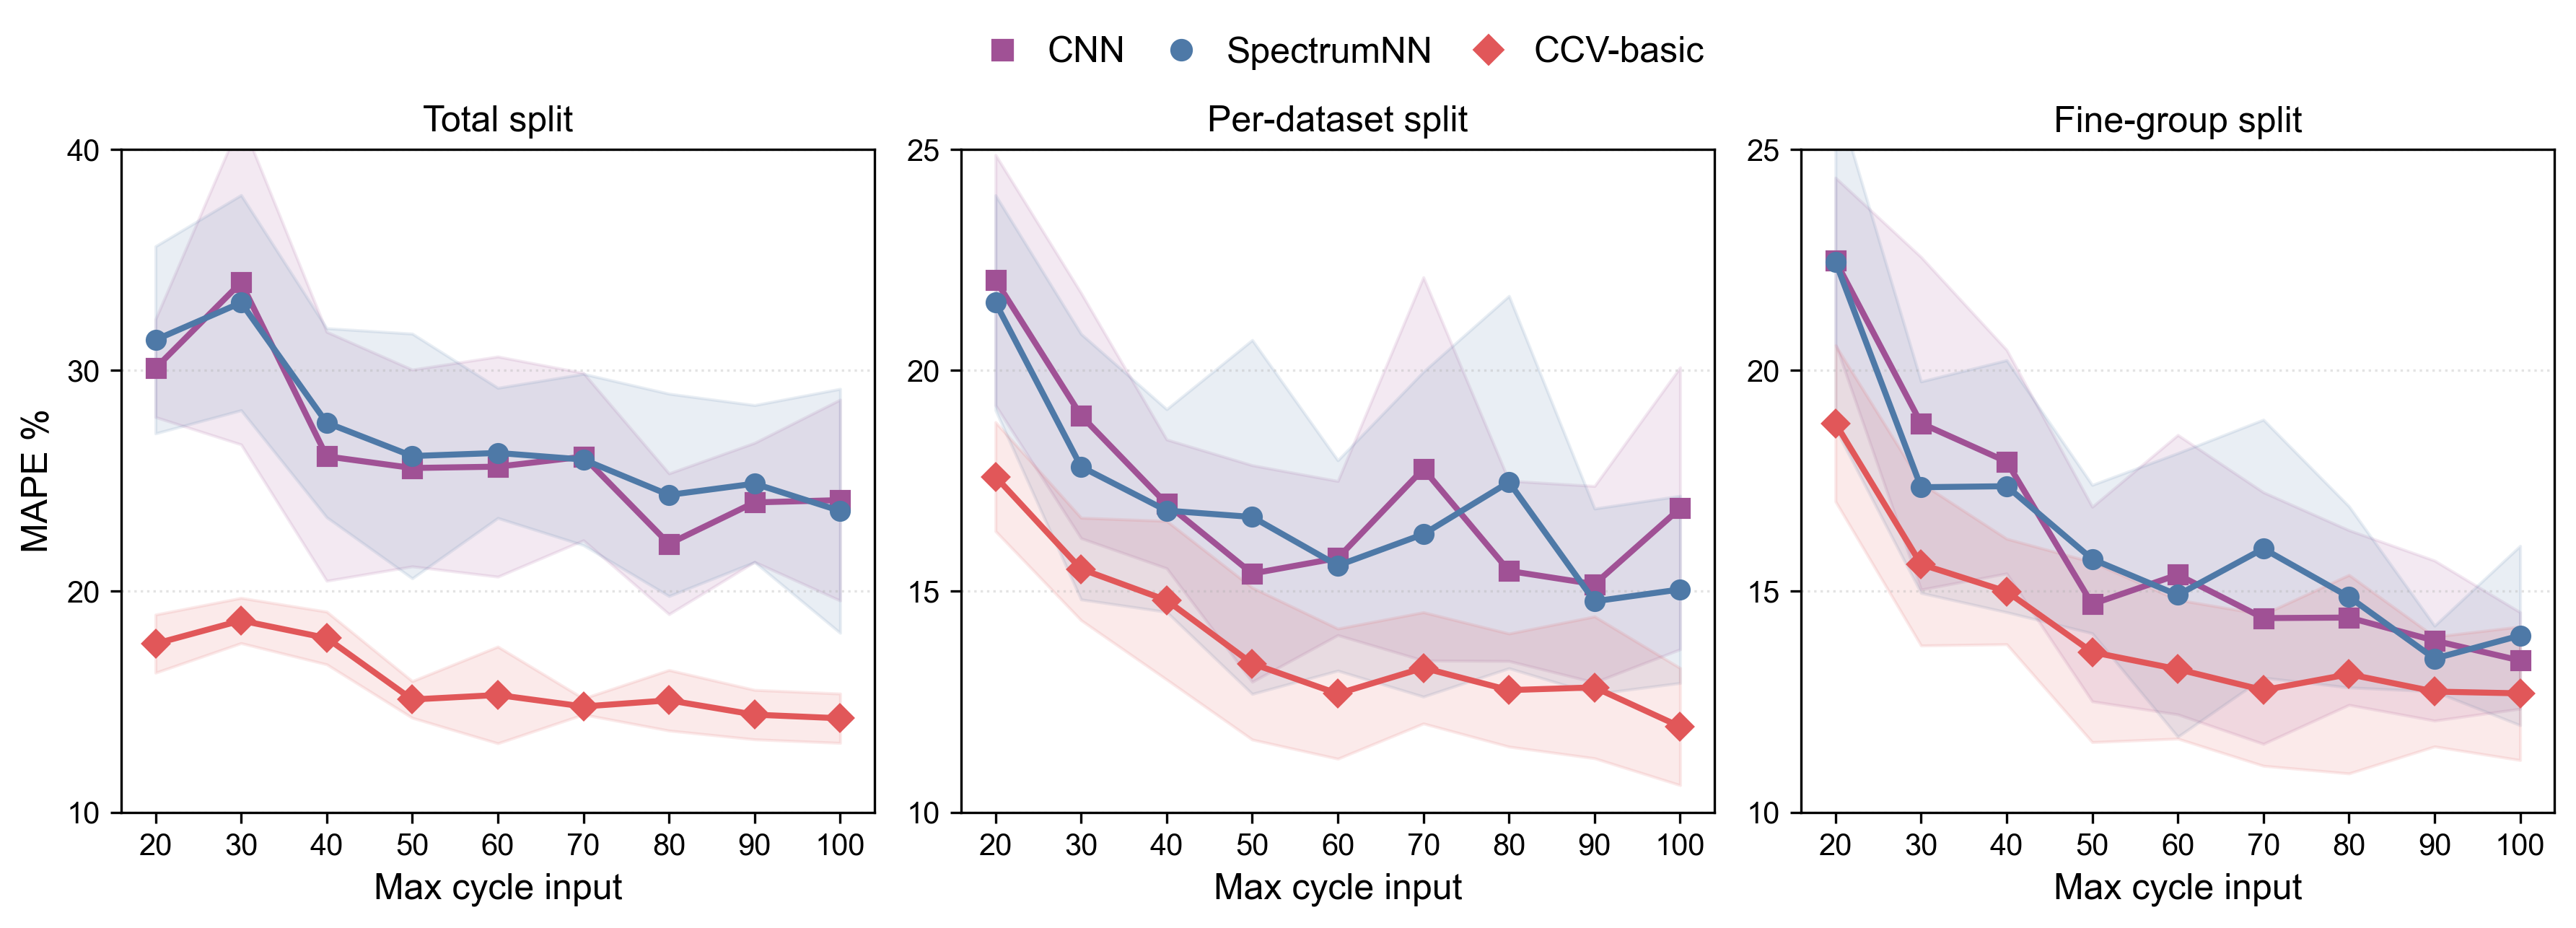

In [ ]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"]
})

plot_df = small_cycle_overall_summary_df.loc[
    small_cycle_overall_summary_df.get("plot_group", "major").astype(str).eq("major") &
    (((small_cycle_overall_summary_df["model"].eq("SpectrumNN")) & (small_cycle_overall_summary_df["input_mode"].eq("norm"))) |
     ((small_cycle_overall_summary_df["model"].eq("CNN")) & (small_cycle_overall_summary_df["input_mode"].eq("norm"))) |
     ((small_cycle_overall_summary_df["model"].eq("CCV-basic")) & (small_cycle_overall_summary_df["input_mode"].eq("abs"))))
].copy()

if plot_df.empty:
    print("No native-input early-cycle major rows found in recovered Module 6 cache.")
else:
    split_order = ["total split", "per-dataset split", "fine-group split"]
    available_splits = [name for name in split_order if name in plot_df["split_protocol"].astype(str).unique().tolist()]
    cycle_order = sorted(plot_df["prefix_end_cycle"].dropna().astype(int).unique().tolist())
    major_specs = [("CNN", "norm"), ("SpectrumNN", "norm"), ("CCV-basic", "abs")]
    label_map = {("CNN", "norm"): "CNN", ("SpectrumNN", "norm"): "SpectrumNN", ("CCV-basic", "abs"): "CCV-basic"}
    palette = {("CNN", "norm"): "#a05195", ("SpectrumNN", "norm"): "#4E79A7", ("CCV-basic", "abs"): "#E15759"}
    
    # Define different markers for each model
    marker_map = {("CNN", "norm"): "s", ("SpectrumNN", "norm"): "o", ("CCV-basic", "abs"): "D"}
    
    # Unify subplot size to match the second code block
    fig, axes = plt.subplots(1, len(available_splits), figsize=(12, 4), dpi=300, squeeze=False)
    
    # Define custom yticks for each subplot
    yticks_config = {
        "total split": {
            "ticks": [10, 20, 30, 40],
            "ylim": (10, 40)
        },
        "per-dataset split": {
            "ticks": [10, 15, 20, 25],
            "ylim": (10, 25)
        },
        "fine-group split": {
            "ticks": [10, 15, 20, 25],
            "ylim": (10, 25)
        }
    }
    
    # Map split names to display labels (used for titles)
    split_display_names = {
        "total split": "Total split",
        "per-dataset split": "Per-dataset split",
        "fine-group split": "Fine-group split"
    }
    
    for ax_idx, (ax, split_name) in enumerate(zip(axes.ravel(), available_splits)):
        split_sub = plot_df.loc[plot_df["split_protocol"].eq(split_name)].copy()
        
        for spec_key in major_specs:
            model_name, input_mode = spec_key
            model_sub = split_sub.loc[split_sub["model"].eq(model_name) & split_sub["input_mode"].eq(input_mode)].sort_values("prefix_end_cycle")
            if model_sub.empty:
                continue
            ax.plot(
                model_sub["prefix_end_cycle"].to_numpy(dtype=int), 
                model_sub["mape"].to_numpy(dtype=float), 
                marker=marker_map[spec_key],
                linewidth=2.0, 
                markersize=6,
                color=palette[spec_key], 
                label=label_map[spec_key]
            )
            ax.fill_between(
                model_sub["prefix_end_cycle"].to_numpy(dtype=int), 
                model_sub["mape"].to_numpy(dtype=float) - model_sub["mape_std"].fillna(0.0).to_numpy(dtype=float), 
                model_sub["mape"].to_numpy(dtype=float) + model_sub["mape_std"].fillna(0.0).to_numpy(dtype=float), 
                color=palette[spec_key], 
                alpha=0.12
            )
        
        ax.set_xlabel("Max cycle input", fontsize=12)
        # Show ylabel only for the first subplot, hide for others (matches second block style)
        if ax_idx == 0:
            ax.set_ylabel("MAPE %", fontsize=12)
        else:
            ax.set_ylabel("")
        
        ax.set_xticks(cycle_order)
        
        # Set custom yticks for each subplot
        if split_name in yticks_config:
            config = yticks_config[split_name]
            ax.set_yticks(config["ticks"])
            ax.set_ylim(config["ylim"][0], config["ylim"][1])
        else:
            ax.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.35)
            continue
        
        ax.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.35)
        
        # Move split mode label to the top of the subplot as title, consistent with second block
        display_name = split_display_names.get(split_name, split_name)
        ax.set_title(display_name, fontsize=12)
    
    # Create custom legend with markers (legend placement matches second block)
    from matplotlib.lines import Line2D
    legend_elements = []
    for spec_key in major_specs:
        model_name, _ = spec_key
        legend_elements.append(
            Line2D(
                [0], [0],
                marker=marker_map[spec_key],
                color='w',
                markerfacecolor=palette[spec_key],
                markersize=6,
                markeredgecolor=palette[spec_key],
                markeredgewidth=1.5,
                label=label_map[spec_key]
            )
        )
    
    fig.legend(
        handles=legend_elements,
        frameon=False,
        fontsize=12,
        loc="upper center",
        ncol=3,
        columnspacing=0.8,
        handlelength=1.5,
        handletextpad=0.5,
        bbox_to_anchor=(0.52, 1.08)   # Exactly matches the second code block
    )
    
    fig.tight_layout()
    #plt.savefig(FIGURE_DIR / "F3d.tiff", dpi=500, format="tiff", bbox_inches="tight")
    plt.show()

In [14]:
# plot_df = small_cycle_overall_summary_df.loc[small_cycle_overall_summary_df.get("plot_group", "major").astype(str).eq("major") & (((small_cycle_overall_summary_df["model"].eq("SpectrumNN")) & (small_cycle_overall_summary_df["input_mode"].eq("norm"))) | ((small_cycle_overall_summary_df["model"].eq("CNN")) & (small_cycle_overall_summary_df["input_mode"].eq("norm"))) | ((small_cycle_overall_summary_df["model"].eq("CCV-basic")) & (small_cycle_overall_summary_df["input_mode"].eq("abs"))))].copy()
# if plot_df.empty:
#     print("No native-input early-cycle major rows found in Small cycle cache.")
# else:
#     plt.rcParams.update({
#         "text.usetex": False,
#         "font.family": "sans-serif",
#         "font.sans-serif": ["Times New Roman"],
#     })

#     split_order = ["total split", "per-dataset split", "fine-group split"]
#     split_display_names = {
#         "total split": "Total split",
#         "per-dataset split": "Per-dataset split",
#         "fine-group split": "Fine-group split",
#     }
#     major_specs = [("CNN", "norm"), ("SpectrumNN", "norm"), ("CCV-basic", "abs")]
#     label_map = {("CNN", "norm"): "CNN", ("SpectrumNN", "norm"): "SpectrumNN", ("CCV-basic", "abs"): "CCV-basic"}
#     palette = {
#         ("CNN", "norm"): "#a05195",
#         ("SpectrumNN", "norm"): "#4E79A7",
#         ("CCV-basic", "abs"): "#E15759",
#     }
#     marker_map = {("CNN", "norm"): "s", ("SpectrumNN", "norm"): "o", ("CCV-basic", "abs"): "D"}

#     cycle_order = sorted(plot_df["prefix_end_cycle"].dropna().astype(int).unique().tolist())
#     normal_gap = 0.5
#     section_gap = 0.5
#     tick_positions, tick_labels, split_midpoints = [], [], []
#     xpos_lookup, cursor = {}, 0.0

#     available_splits = [name for name in split_order if name in plot_df["split_protocol"].astype(str).unique().tolist()]
#     for split_idx, split_name in enumerate(available_splits):
#         local_positions = []
#         for cycle in cycle_order:
#             xpos_lookup[(split_name, cycle)] = cursor
#             local_positions.append(cursor)
#             tick_positions.append(cursor)
#             tick_labels.append(str(int(cycle)))
#             cursor += normal_gap
#         split_midpoints.append((split_name, float(np.mean(local_positions))))
#         if split_idx < len(available_splits) - 1:
#             cursor += section_gap

#     fig, ax = plt.subplots(figsize=(12.5, 4), dpi=300)

#     for model_name, input_mode in major_specs:
#         model_sub = plot_df.loc[
#             plot_df["model"].eq(model_name) & plot_df["input_mode"].eq(input_mode)
#         ].copy()
#         spec_key = (model_name, input_mode)

#         for split_name in available_splits:
#             split_model_sub = model_sub.loc[model_sub["split_protocol"].eq(split_name)].copy()
#             if split_model_sub.empty:
#                 continue
#             split_model_sub = split_model_sub.sort_values("prefix_end_cycle")
#             xvals = [xpos_lookup[(split_name, int(v))] for v in split_model_sub["prefix_end_cycle"].to_numpy(dtype=int)]
#             yvals = split_model_sub["mape"].to_numpy(dtype=float)
#             std_vals = split_model_sub["mape_std"].fillna(0.0).to_numpy(dtype=float) if "mape_std" in split_model_sub.columns else np.zeros(len(yvals), dtype=float)

#             ax.plot(
#                 xvals,
#                 yvals,
#                 color=palette[spec_key],
#                 marker=marker_map[spec_key],
#                 linewidth=2.0,
#                 markersize=5.5,
#                 label=label_map[spec_key] if split_name == available_splits[0] else None,
#             )
#             ax.fill_between(
#                 xvals,
#                 yvals - std_vals,
#                 yvals + std_vals,
#                 color=palette[spec_key],
#                 alpha=0.12,
#             )

#     for idx in range(len(available_splits) - 1):
#         left_center = xpos_lookup[(available_splits[idx], cycle_order[-1])]
#         right_center = xpos_lookup[(available_splits[idx + 1], cycle_order[0])]
#         ax.axvline(0.5 * (left_center + right_center), color="#999999", linestyle="--", linewidth=0.8, alpha=0.75)

#     for split_name, xpos in split_midpoints:
#         ax.text(
#             xpos,
#             39.2,
#             split_display_names.get(split_name, split_name),
#             ha="center",
#             va="top",
#             fontsize=12,
#         )

#     ax.set_xticks(tick_positions)
#     ax.set_xticklabels(tick_labels, fontsize=10)
#     if tick_positions:
#         ax.set_xlim(min(tick_positions) - 1 * normal_gap, max(tick_positions) + 1 * normal_gap)
#     ax.set_xlabel("Max input feature cycle ", fontsize=12)
#     ax.set_ylabel("MAPE %", fontsize=12)
#     ax.set_ylim(10, 40)
#     ax.set_yticks([10, 15, 20, 25, 30, 35, 40])
#     ax.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.35)
#     fig.legend(frameon=False, fontsize=12, bbox_to_anchor=(0.52, 0.98), ncol=3, loc="center")
#     fig.tight_layout()
#     plt.show()

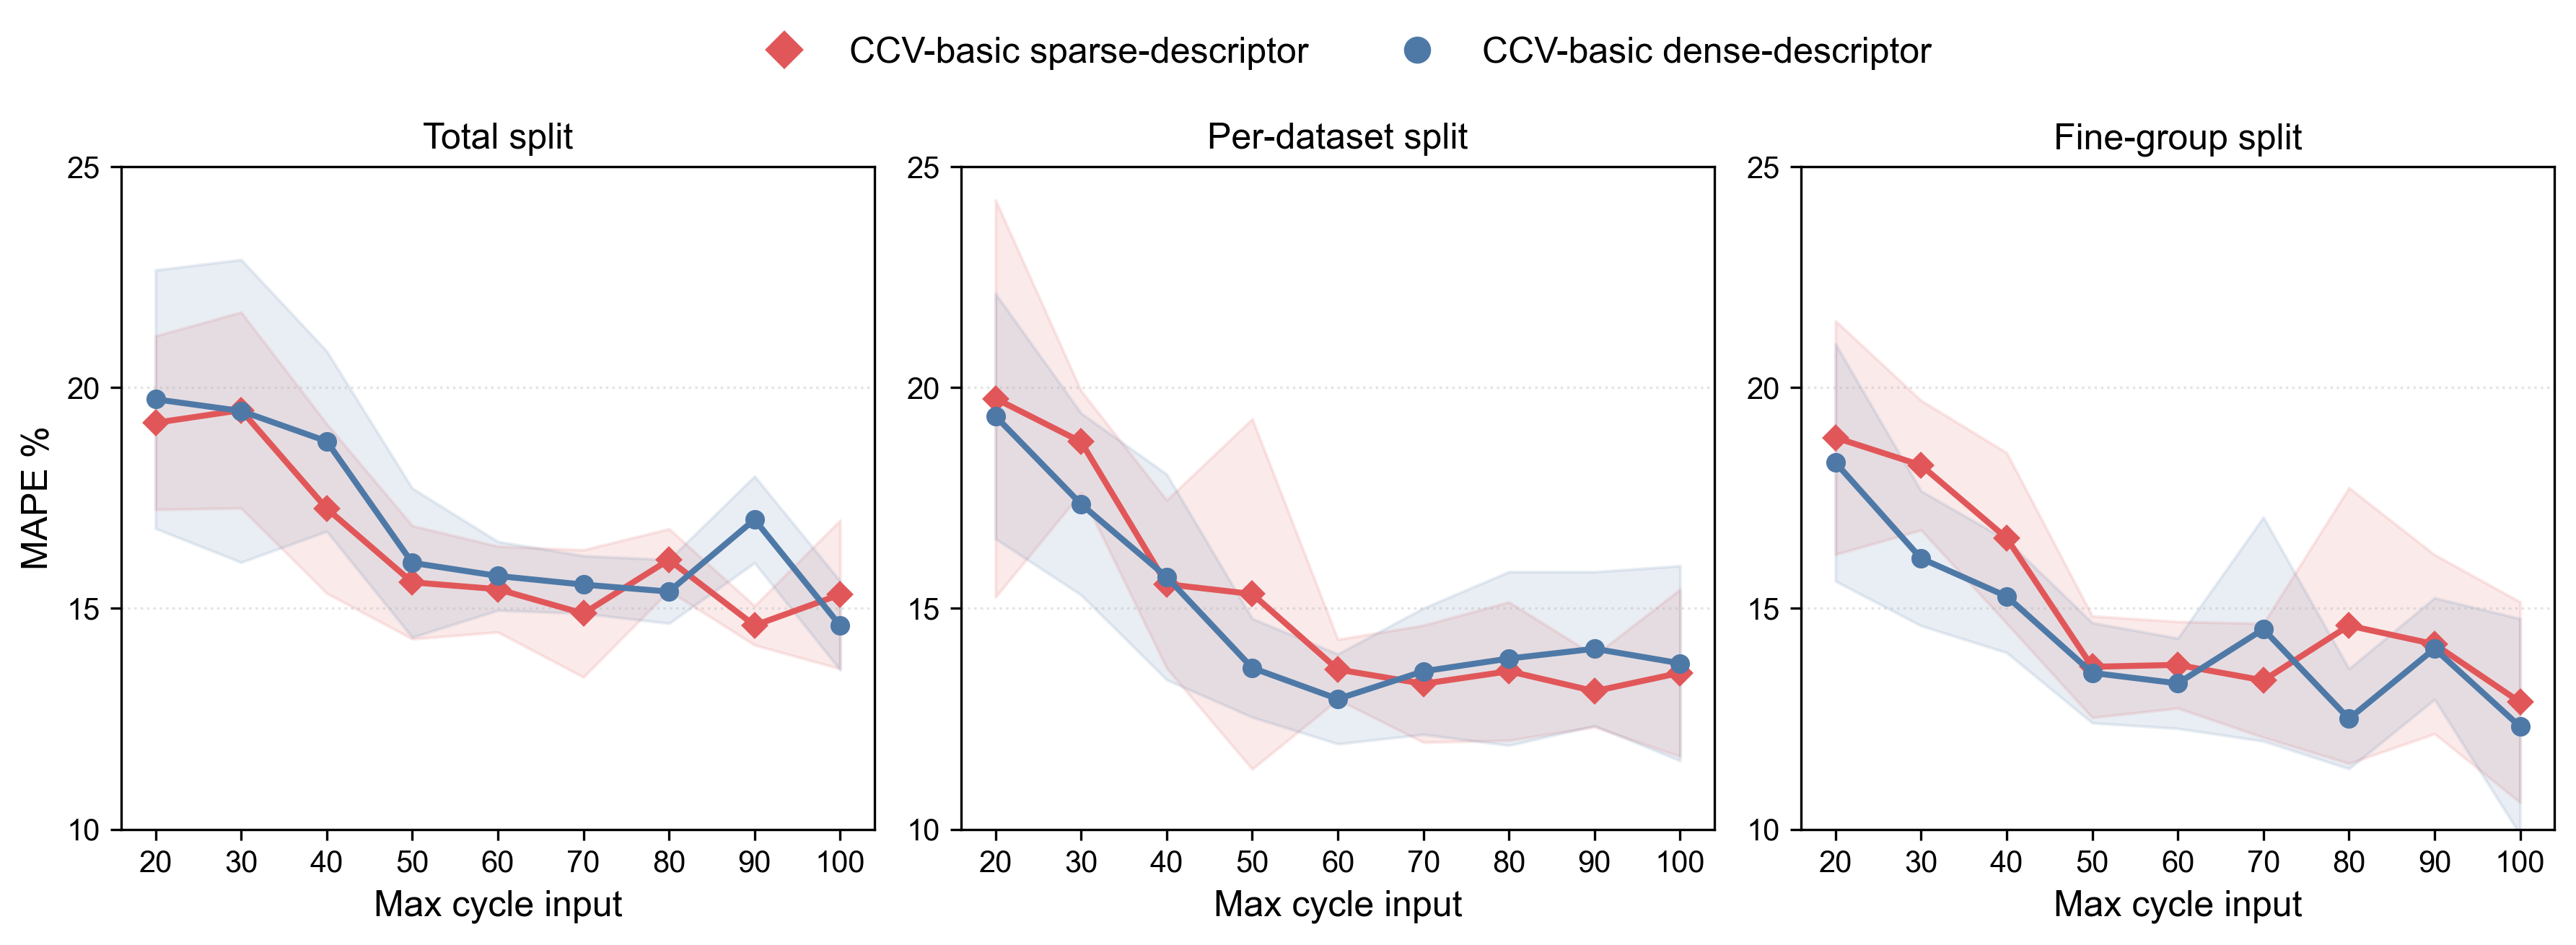

In [ ]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"]
})

plot_df = small_cycle_attr_overall_summary_df.copy()
if plot_df.empty:
    print("No descriptor-density rows found in Small cycle cache.")
else:
    split_order = ["total split", "per-dataset split", "fine-group split"]
    available_splits = [name for name in split_order if name in plot_df["split_protocol"].astype(str).unique().tolist()]
    method_order = ["CCV-basic sparse-desc", "CCV-basic dense-desc"]
    label_map = {
        "CCV-basic sparse-desc": "CCV-basic sparse-descriptor",
        "CCV-basic dense-desc": "CCV-basic dense-descriptor",
    }
    palette = {
        "CCV-basic sparse-desc": "#E15759",
        "CCV-basic dense-desc": "#4E79A7",
    }
    marker_map = {
        "CCV-basic sparse-desc": "D",
        "CCV-basic dense-desc": "o",
    }

    # -------- Unify figure size to (12, 4) to match the first code block --------
    fig, axes = plt.subplots(1, len(available_splits), figsize=(12, 4), dpi=300, squeeze=False)

    # Fix y-axis range to 10~25 for all subplots, with consistent ticks
    yticks = [10, 15, 20, 25]
    ylim = (10, 25)

    split_display_names = {
        "total split": "Total split",
        "per-dataset split": "Per-dataset split",
        "fine-group split": "Fine-group split"
    }

    for ax, split_name in zip(axes.ravel(), available_splits):
        split_sub = plot_df.loc[plot_df["split_protocol"].eq(split_name)].copy()

        for method_name in method_order:
            method_sub = split_sub.loc[split_sub["method"].eq(method_name)].sort_values("prefix_end_cycle")
            if method_sub.empty:
                continue
            ax.plot(
                method_sub["prefix_end_cycle"].to_numpy(dtype=int),
                method_sub["mape"].to_numpy(dtype=float),
                color=palette[method_name],
                marker=marker_map[method_name],
                linewidth=2.0,
                markersize=5.5,
                label=label_map[method_name]
            )
            # Shaded regions represent standard deviation (std)
            std_values = method_sub["mape_std"].fillna(0.0).to_numpy(dtype=float) if "mape_std" in method_sub.columns else np.zeros(len(method_sub), dtype=float)
            ax.fill_between(
                method_sub["prefix_end_cycle"].to_numpy(dtype=int),
                method_sub["mape"].to_numpy(dtype=float) - std_values,
                method_sub["mape"].to_numpy(dtype=float) + std_values,
                color=palette[method_name],
                alpha=0.12
            )

        ax.set_title(split_display_names.get(split_name, split_name), fontsize=12)
        ax.set_xlabel("Max cycle input", fontsize=12)
        # Show ylabel only for the first subplot to match the previous style
        if ax == axes.ravel()[0]:
            ax.set_ylabel("MAPE %", fontsize=12)
        else:
            ax.set_ylabel("")

        ax.set_ylim(*ylim)
        ax.set_yticks(yticks)
        ax.set_xticks(list(PREFIX_CYCLES))
        ax.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.35)

    # -------- Custom legend: show markers only, no lines --------
    from matplotlib.lines import Line2D
    legend_elements = []
    for method_name in method_order:
        legend_elements.append(
            Line2D(
                [0], [0],
                marker=marker_map[method_name],
                color='w',                          # Set line color to white to make it invisible
                markerfacecolor=palette[method_name],
                markersize=8,
                markeredgecolor=palette[method_name],
                markeredgewidth=1.0,
                label=label_map[method_name]
            )
        )

    fig.legend(
        handles=legend_elements,
        frameon=False,
        fontsize=12,
        loc="upper center",
        ncol=2,
        bbox_to_anchor=(0.52, 1.1)   # Exactly matches the first code block
    )

    fig.tight_layout()
    #plt.savefig(FIGURE_DIR / "S9-1.tiff", format="tiff", dpi=500, bbox_inches="tight")
    plt.show()

In [16]:
summary_df = small_cycle_attr_overall_summary_df.copy()

if summary_df.empty:
    print("No rows found in small_cycle_attr_overall_summary_df.")
else:
    keep_methods = ["CCV-basic sparse-desc", "CCV-basic dense-desc"]
    work_df = summary_df.loc[summary_df["method"].isin(keep_methods)].copy()

    pivot_df = (
        work_df.pivot_table(
            index="split_protocol",
            columns="method",
            values=["mape", "rmse", "pearson_r"],
            aggfunc="mean",
        )
        .reset_index()
    )

    pivot_df.columns = [
        "_".join([str(x) for x in col if str(x) != ""]).strip("_")
        if isinstance(col, tuple) else str(col)
        for col in pivot_df.columns
    ]

    result_df = pd.DataFrame({
        "split_protocol": pivot_df["split_protocol"],
        "sparse_mape": pivot_df["mape_CCV-basic sparse-desc"],
        "dense_mape": pivot_df["mape_CCV-basic dense-desc"],
        "delta_mape": pivot_df["mape_CCV-basic dense-desc"] - pivot_df["mape_CCV-basic sparse-desc"],
        "mape_gain_pct_vs_sparse": 100.0 * (
            pivot_df["mape_CCV-basic sparse-desc"] - pivot_df["mape_CCV-basic dense-desc"]
        ) / pivot_df["mape_CCV-basic sparse-desc"].clip(lower=1e-8),

        "sparse_rmse": pivot_df["rmse_CCV-basic sparse-desc"],
        "dense_rmse": pivot_df["rmse_CCV-basic dense-desc"],
        "delta_rmse": pivot_df["rmse_CCV-basic dense-desc"] - pivot_df["rmse_CCV-basic sparse-desc"],

        "sparse_pearson": pivot_df["pearson_r_CCV-basic sparse-desc"],
        "dense_pearson": pivot_df["pearson_r_CCV-basic dense-desc"],
        "delta_pearson": pivot_df["pearson_r_CCV-basic dense-desc"] - pivot_df["pearson_r_CCV-basic sparse-desc"],
    })

    split_order = ["total split", "per-dataset split", "fine-group split"]
    result_df["split_protocol"] = pd.Categorical(result_df["split_protocol"], categories=split_order, ordered=True)
    result_df = result_df.sort_values("split_protocol").reset_index(drop=True)

    print("Dense vs sparse descriptor overall difference by split:")
    display(result_df.round(3))


SMALL_CYCLE_OUT_CSV = TABLE_DIR / "small_cycle_SI_result.csv"
if small_cycle_overall_summary_df.empty:
    print("[Small cycle SI] No summary rows available.")
else:
    # small_cycle_overall_summary_df.to_csv(SMALL_CYCLE_OUT_CSV, index=False, encoding="utf-8-sig")
    print(f"Small cycle SI_result saved to: {SMALL_CYCLE_OUT_CSV}")


Dense vs sparse descriptor overall difference by split:


,split_protocol,sparse_mape,dense_mape,delta_mape,mape_gain_pct_vs_sparse,sparse_rmse,dense_rmse,delta_rmse,sparse_pearson,dense_pearson,delta_pearson
0,total split,16.433,16.923,0.489,-2.979,203.934,210.463,6.530,0.914,0.907,-0.006
1,per-dataset split,15.173,14.924,-0.249,1.640,196.680,197.299,0.619,0.918,0.918,-0.000
2,fine-group split,15.128,14.445,-0.683,4.516,197.185,193.675,-3.510,0.918,0.921,0.004


Small cycle SI_result saved to: c:\Users\laipeiheng\Desktop\CCVNet\results\tables\small_cycle_SI_result.csv


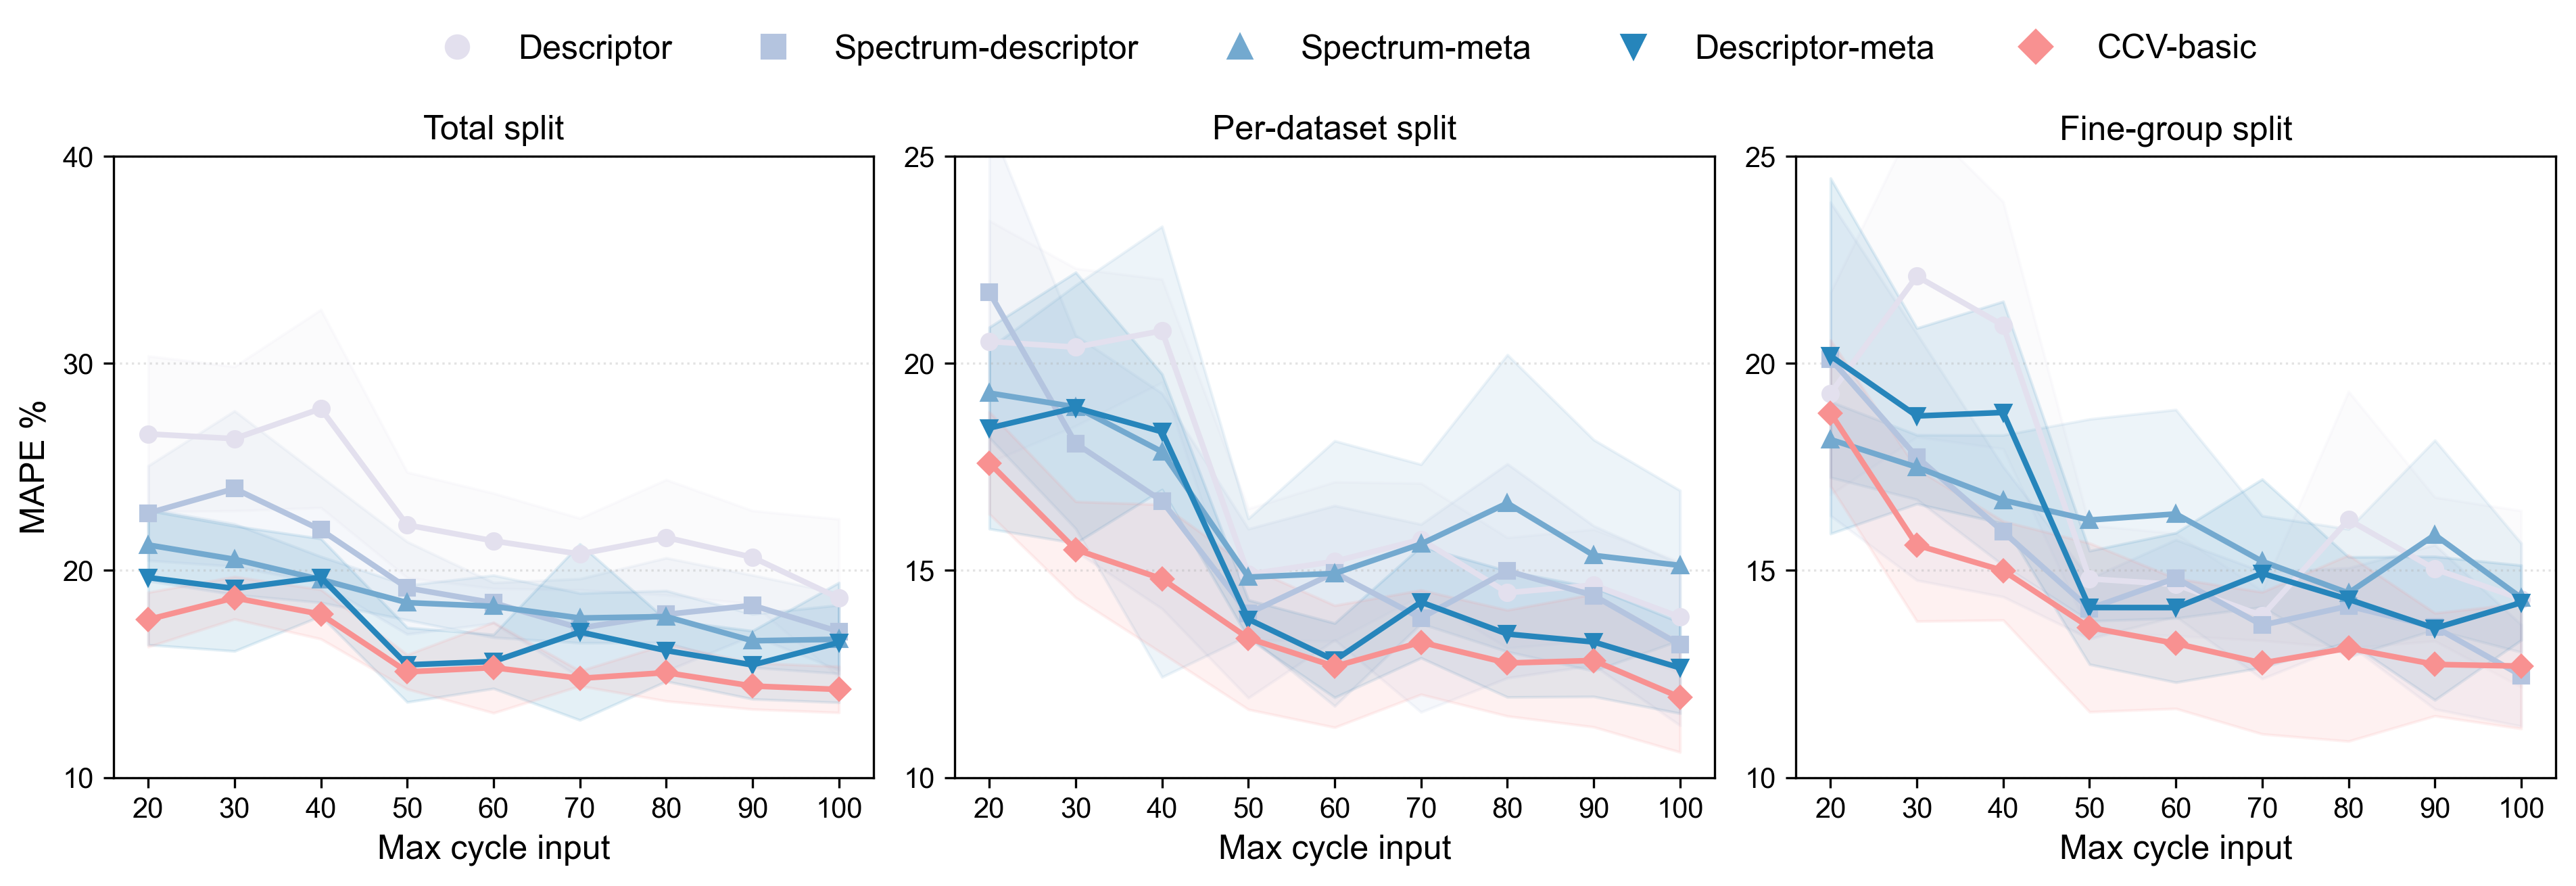

In [ ]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"]
})

import seaborn as sns
from matplotlib.lines import Line2D

compare_mode = "abs"
plot_df = pd.concat(
    [
        small_cycle_overall_summary_df.loc[
            (
                (
                    small_cycle_overall_summary_df.get("plot_group", "major").astype(str).eq("major")
                    & small_cycle_overall_summary_df["model"].eq("CCV-basic")
                    & small_cycle_overall_summary_df["input_mode"].eq("abs")
                )
                | (
                    small_cycle_overall_summary_df.get("plot_group", "ablation").astype(str).eq("ablation")
                    & small_cycle_overall_summary_df["model"].eq("CCV-norm")
                    & small_cycle_overall_summary_df["input_mode"].eq("norm")
                )
            )
        ].copy(),
        small_cycle_overall_summary_df.loc[
            small_cycle_overall_summary_df.get("plot_group", "ablation").astype(str).eq("ablation")
            & small_cycle_overall_summary_df["input_mode"].eq(compare_mode)
            & small_cycle_overall_summary_df["model"].isin([
                "Descriptor",
                "Spectrum-descriptor",
                "Spectrum-meta",
                "Descriptor-meta",
            ])
        ].copy(),
    ],
    ignore_index=True,
)

if plot_df.empty:
    print("No CCV-reference / abs-ablation comparison rows found in Small cycle cache.")
else:
    split_order = ["total split", "per-dataset split", "fine-group split"]
    available_splits = [name for name in split_order if name in plot_df["split_protocol"].astype(str).unique().tolist()]
    cycle_order = sorted(plot_df["prefix_end_cycle"].dropna().astype(int).unique().tolist())
    compare_specs = [
        ("Descriptor", compare_mode, "ablation"),
        ("Spectrum-descriptor", compare_mode, "ablation"),
        ("Spectrum-meta", compare_mode, "ablation"),
        ("Descriptor-meta", compare_mode, "ablation"),
        ("CCV-basic", "abs", "major") if compare_mode == "abs" else ("CCV-norm", "norm", "ablation"),
    ]
    label_map = {
        ("Descriptor", compare_mode, "ablation"): "Descriptor",
        ("Spectrum-descriptor", compare_mode, "ablation"): "Spectrum-descriptor",
        ("Spectrum-meta", compare_mode, "ablation"): "Spectrum-meta",
        ("Descriptor-meta", compare_mode, "ablation"): "Descriptor-meta",
        ("CCV-basic", "abs", "major"): "CCV-basic",
        ("CCV-norm", "norm", "ablation"): "CCV-norm",
    }
    pubu_colors = sns.color_palette("PuBu", 5)
    palette = {
        ("Descriptor", compare_mode, "ablation"): pubu_colors[0],
        ("Spectrum-descriptor", compare_mode, "ablation"): pubu_colors[1],
        ("Spectrum-meta", compare_mode, "ablation"): pubu_colors[2],
        ("Descriptor-meta", compare_mode, "ablation"): pubu_colors[3],
        ("CCV-basic", "abs", "major"): "#f89191",
        ("CCV-norm", "norm", "ablation"): "#f89191",
    }
    marker_map = {
        ("Descriptor", compare_mode, "ablation"): "o",
        ("Spectrum-descriptor", compare_mode, "ablation"): "s",
        ("Spectrum-meta", compare_mode, "ablation"): "^",
        ("Descriptor-meta", compare_mode, "ablation"): "v",
        ("CCV-basic", "abs", "major"): "D",
        ("CCV-norm", "norm", "ablation"): "D",
    }
    yticks_config = {
        "total split": {"ticks": [10, 20, 30, 40], "ylim": (10, 40)},
        "per-dataset split": {"ticks": [10, 15, 20, 25], "ylim": (10, 25)},
        "fine-group split": {"ticks": [10, 15, 20, 25], "ylim": (10, 25)},
    }
    split_display_names = {
        "total split": "Total split",
        "per-dataset split": "Per-dataset split",
        "fine-group split": "Fine-group split",
    }

    fig, axes = plt.subplots(1, len(available_splits), figsize=(12.8, 4), dpi=300, squeeze=False)

    for ax_idx, (ax, split_name) in enumerate(zip(axes.ravel(), available_splits)):
        split_sub = plot_df.loc[plot_df["split_protocol"].eq(split_name)].copy()

        for spec_key in compare_specs:
            model_name, input_mode, plot_group = spec_key
            model_sub = split_sub.loc[
                split_sub["model"].eq(model_name)
                & split_sub["input_mode"].eq(input_mode)
                & split_sub["plot_group"].eq(plot_group)
            ].sort_values("prefix_end_cycle")
            if model_sub.empty:
                continue
            ax.plot(
                model_sub["prefix_end_cycle"].to_numpy(dtype=int),
                model_sub["mape"].to_numpy(dtype=float),
                marker=marker_map[spec_key],
                linewidth=2.0,
                markersize=5.5,
                color=palette[spec_key],
                label=label_map[spec_key],
            )
            ax.fill_between(
                model_sub["prefix_end_cycle"].to_numpy(dtype=int),
                model_sub["mape"].to_numpy(dtype=float) - model_sub["mape_std"].fillna(0.0).to_numpy(dtype=float),
                model_sub["mape"].to_numpy(dtype=float) + model_sub["mape_std"].fillna(0.0).to_numpy(dtype=float),
                color=palette[spec_key],
                alpha=0.12,
            )

        ax.set_xlabel("Max cycle input", fontsize=12)
        if ax_idx == 0:
            ax.set_ylabel("MAPE %", fontsize=12)
        else:
            ax.set_ylabel("")
        ax.set_xticks(cycle_order)
        if split_name in yticks_config:
            config = yticks_config[split_name]
            ax.set_yticks(config["ticks"])
            ax.set_ylim(config["ylim"][0], config["ylim"][1])
        ax.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.35)
        ax.set_title(split_display_names.get(split_name, split_name), fontsize=12)

    legend_elements = []
    for spec_key in compare_specs:
        legend_elements.append(
            Line2D(
                [0], [0],
                marker=marker_map[spec_key],
                color="w",
                markerfacecolor=palette[spec_key],
                markersize=8,
                markeredgecolor=palette[spec_key],
                markeredgewidth=1.0,
                label=label_map[spec_key],
            )
        )

    fig.legend(
        handles=legend_elements,
        frameon=False,
        fontsize=12,
        loc="upper center",
        ncol=5,
        bbox_to_anchor=(0.52, 1.10),
    )

    fig.tight_layout()
    #plt.savefig(FIGURE_DIR / "S12-5.tiff", format="tiff", dpi=500, bbox_inches="tight")
    plt.show()


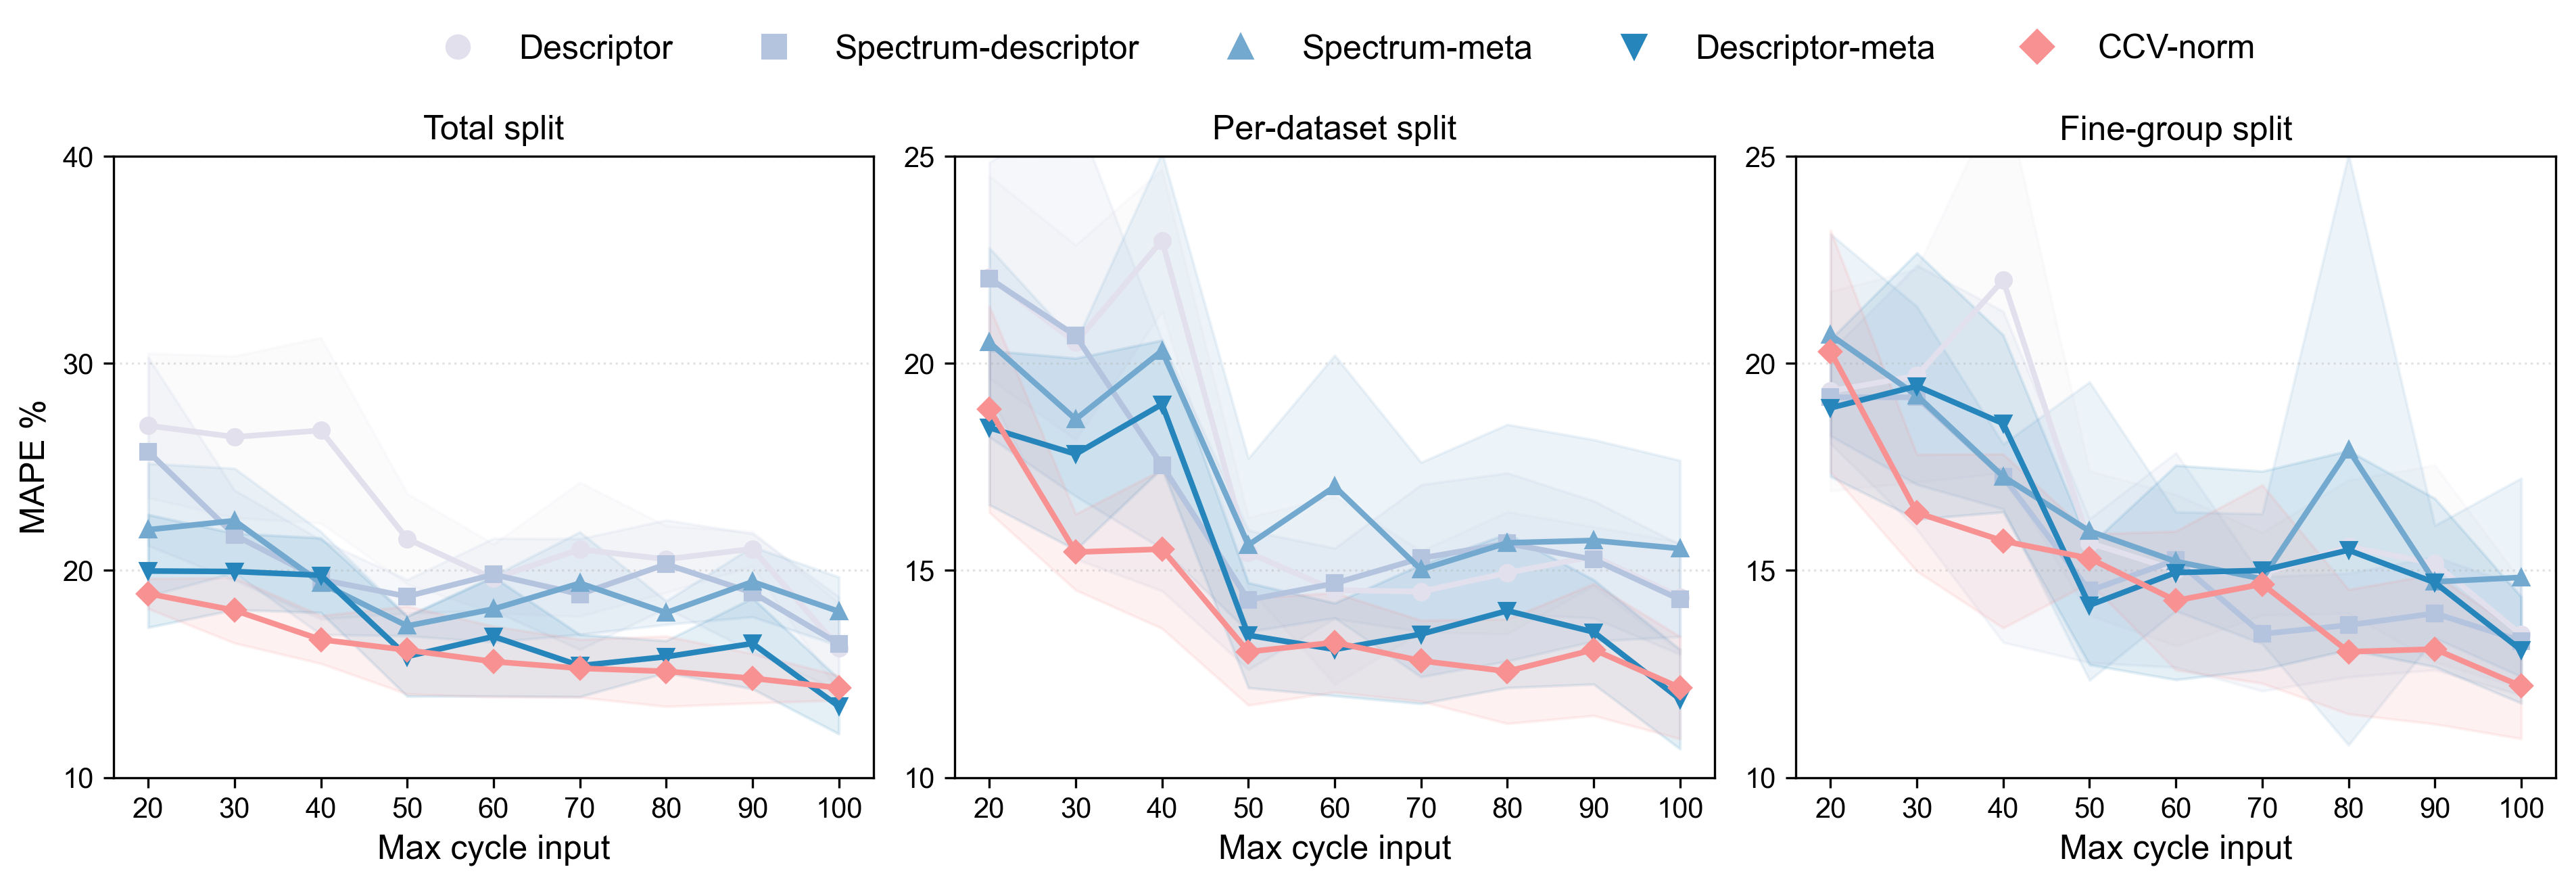

In [ ]:
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"]
})

import seaborn as sns
from matplotlib.lines import Line2D

compare_mode = "norm"
plot_df = pd.concat(
    [
        small_cycle_overall_summary_df.loc[
            (
                (
                    small_cycle_overall_summary_df.get("plot_group", "major").astype(str).eq("major")
                    & small_cycle_overall_summary_df["model"].eq("CCV-basic")
                    & small_cycle_overall_summary_df["input_mode"].eq("abs")
                )
                | (
                    small_cycle_overall_summary_df.get("plot_group", "ablation").astype(str).eq("ablation")
                    & small_cycle_overall_summary_df["model"].eq("CCV-norm")
                    & small_cycle_overall_summary_df["input_mode"].eq("norm")
                )
            )
        ].copy(),
        small_cycle_overall_summary_df.loc[
            small_cycle_overall_summary_df.get("plot_group", "ablation").astype(str).eq("ablation")
            & small_cycle_overall_summary_df["input_mode"].eq(compare_mode)
            & small_cycle_overall_summary_df["model"].isin([
                "Descriptor",
                "Spectrum-descriptor",
                "Spectrum-meta",
                "Descriptor-meta",
            ])
        ].copy(),
    ],
    ignore_index=True,
)

if plot_df.empty:
    print("No CCV-reference / norm-ablation comparison rows found in Small cycle cache.")
else:
    split_order = ["total split", "per-dataset split", "fine-group split"]
    available_splits = [name for name in split_order if name in plot_df["split_protocol"].astype(str).unique().tolist()]
    cycle_order = sorted(plot_df["prefix_end_cycle"].dropna().astype(int).unique().tolist())
    compare_specs = [
        ("Descriptor", compare_mode, "ablation"),
        ("Spectrum-descriptor", compare_mode, "ablation"),
        ("Spectrum-meta", compare_mode, "ablation"),
        ("Descriptor-meta", compare_mode, "ablation"),
        ("CCV-basic", "abs", "major") if compare_mode == "abs" else ("CCV-norm", "norm", "ablation"),
    ]
    label_map = {
        ("Descriptor", compare_mode, "ablation"): "Descriptor",
        ("Spectrum-descriptor", compare_mode, "ablation"): "Spectrum-descriptor",
        ("Spectrum-meta", compare_mode, "ablation"): "Spectrum-meta",
        ("Descriptor-meta", compare_mode, "ablation"): "Descriptor-meta",
        ("CCV-basic", "abs", "major"): "CCV-basic",
        ("CCV-norm", "norm", "ablation"): "CCV-norm",
    }
    pubu_colors = sns.color_palette("PuBu", 5)
    palette = {
        ("Descriptor", compare_mode, "ablation"): pubu_colors[0],
        ("Spectrum-descriptor", compare_mode, "ablation"): pubu_colors[1],
        ("Spectrum-meta", compare_mode, "ablation"): pubu_colors[2],
        ("Descriptor-meta", compare_mode, "ablation"): pubu_colors[3],
        ("CCV-basic", "abs", "major"): "#f89191",
        ("CCV-norm", "norm", "ablation"): "#f89191",
    }
    marker_map = {
        ("Descriptor", compare_mode, "ablation"): "o",
        ("Spectrum-descriptor", compare_mode, "ablation"): "s",
        ("Spectrum-meta", compare_mode, "ablation"): "^",
        ("Descriptor-meta", compare_mode, "ablation"): "v",
        ("CCV-basic", "abs", "major"): "D",
        ("CCV-norm", "norm", "ablation"): "D",
    }
    yticks_config = {
        "total split": {"ticks": [10, 20, 30, 40], "ylim": (10, 40)},
        "per-dataset split": {"ticks": [10, 15, 20, 25], "ylim": (10, 25)},
        "fine-group split": {"ticks": [10, 15, 20, 25], "ylim": (10, 25)},
    }
    split_display_names = {
        "total split": "Total split",
        "per-dataset split": "Per-dataset split",
        "fine-group split": "Fine-group split",
    }

    fig, axes = plt.subplots(1, len(available_splits), figsize=(12.8, 4), dpi=300, squeeze=False)

    for ax_idx, (ax, split_name) in enumerate(zip(axes.ravel(), available_splits)):
        split_sub = plot_df.loc[plot_df["split_protocol"].eq(split_name)].copy()

        for spec_key in compare_specs:
            model_name, input_mode, plot_group = spec_key
            model_sub = split_sub.loc[
                split_sub["model"].eq(model_name)
                & split_sub["input_mode"].eq(input_mode)
                & split_sub["plot_group"].eq(plot_group)
            ].sort_values("prefix_end_cycle")
            if model_sub.empty:
                continue
            ax.plot(
                model_sub["prefix_end_cycle"].to_numpy(dtype=int),
                model_sub["mape"].to_numpy(dtype=float),
                marker=marker_map[spec_key],
                linewidth=2.0,
                markersize=5.5,
                color=palette[spec_key],
                label=label_map[spec_key],
            )
            ax.fill_between(
                model_sub["prefix_end_cycle"].to_numpy(dtype=int),
                model_sub["mape"].to_numpy(dtype=float) - model_sub["mape_std"].fillna(0.0).to_numpy(dtype=float),
                model_sub["mape"].to_numpy(dtype=float) + model_sub["mape_std"].fillna(0.0).to_numpy(dtype=float),
                color=palette[spec_key],
                alpha=0.12,
            )

        ax.set_xlabel("Max cycle input", fontsize=12)
        if ax_idx == 0:
            ax.set_ylabel("MAPE %", fontsize=12)
        else:
            ax.set_ylabel("")
        ax.set_xticks(cycle_order)
        if split_name in yticks_config:
            config = yticks_config[split_name]
            ax.set_yticks(config["ticks"])
            ax.set_ylim(config["ylim"][0], config["ylim"][1])
        ax.grid(axis="y", linestyle=":", linewidth=0.8, alpha=0.35)
        ax.set_title(split_display_names.get(split_name, split_name), fontsize=12)

    legend_elements = []
    for spec_key in compare_specs:
        legend_elements.append(
            Line2D(
                [0], [0],
                marker=marker_map[spec_key],
                color="w",
                markerfacecolor=palette[spec_key],
                markersize=8,
                markeredgecolor=palette[spec_key],
                markeredgewidth=1.0,
                label=label_map[spec_key],
            )
        )

    fig.legend(
        handles=legend_elements,
        frameon=False,
        fontsize=12,
        loc="upper center",
        ncol=5,
        bbox_to_anchor=(0.52, 1.10),
    )

    fig.tight_layout()
    #plt.savefig(FIGURE_DIR / "S12-6.tiff", format="tiff", dpi=500, bbox_inches="tight")
    plt.show()
